# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df = pd.read_csv('data/regression.csv')

X = df[['num_commits', 'AVG(diff)']] 
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   AVG(diff)    29 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 592.0 bytes


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

Оценки Silhouette Score для разных n_clusters:
n_clusters=2: silhouette_score = 0.41949
n_clusters=3: silhouette_score = 0.44544
n_clusters=4: silhouette_score = 0.41504
n_clusters=5: silhouette_score = 0.35210
n_clusters=6: silhouette_score = 0.39544
n_clusters=7: silhouette_score = 0.39637
n_clusters=8: silhouette_score = 0.48638
n_clusters=9: silhouette_score = 0.45377
n_clusters=10: silhouette_score = 0.42633

Победитель: n_clusters=8 с оценкой 0.48638


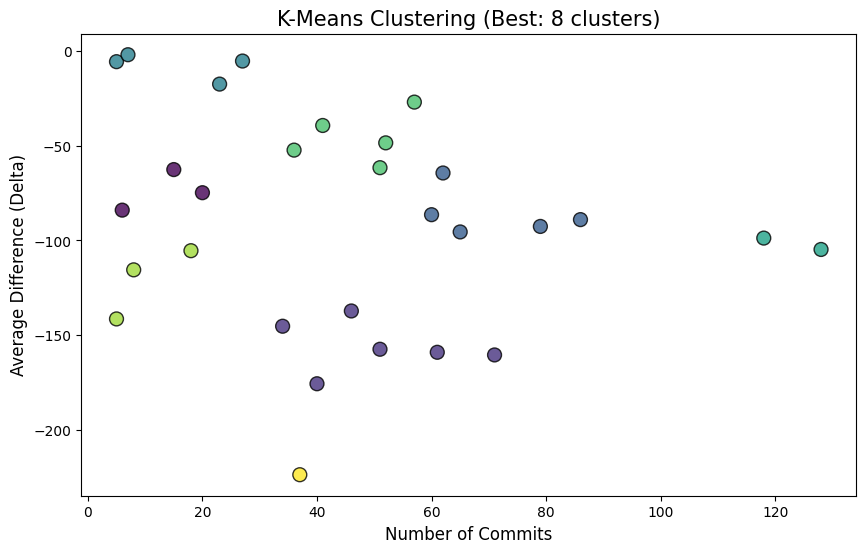

In [3]:
best_score = -1
best_n = -1
best_labels = None

print("Оценки Silhouette Score для разных n_clusters:")

for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, random_state=21)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    print(f"n_clusters={n}: silhouette_score = {score:.5f}")
    
    if score > best_score:
        best_score = score
        best_n = n
        best_labels = labels

print(f"\nПобедитель: n_clusters={best_n} с оценкой {best_score:.5f}")

plt.figure(figsize=(10, 6))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=best_labels, cmap='viridis', 
            s=100, edgecolor='black', alpha=0.8)
plt.title(f'K-Means Clustering (Best: {best_n} clusters)', fontsize=15)
plt.xlabel('Number of Commits', fontsize=12)
plt.ylabel('Average Difference (Delta)', fontsize=12)
plt.show()

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

Ищем лучшую комбинацию eps и min_samples...

Победитель: eps=22, min_samples=1
Оценка Silhouette Score: 0.48713


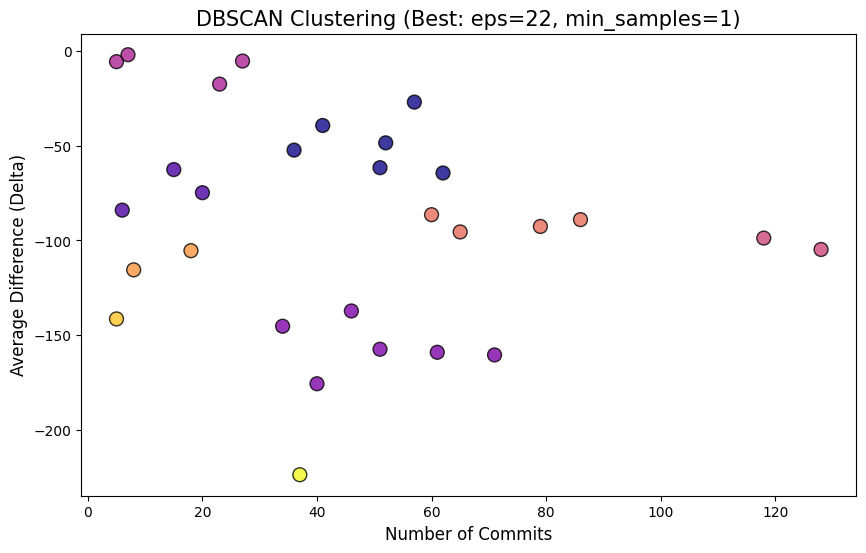

In [4]:
best_score_db = -1
best_eps = -1
best_min_samples = -1
best_labels_db = None

print("Ищем лучшую комбинацию eps и min_samples...\n")

for eps_val in range(10, 36):
    for min_s in range(1, 6):
        dbscan = DBSCAN(eps=eps_val, min_samples=min_s)
        labels = dbscan.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        

        if len(set(labels)) > 1 and n_clusters >= 1:
            score = silhouette_score(X, labels)
            
            if score > best_score_db:
                best_score_db = score
                best_eps = eps_val
                best_min_samples = min_s
                best_labels_db = labels

print(f"Победитель: eps={best_eps}, min_samples={best_min_samples}")
print(f"Оценка Silhouette Score: {best_score_db:.5f}")

plt.figure(figsize=(10, 6))

plt.scatter(X['num_commits'], X['AVG(diff)'], c=best_labels_db, cmap='plasma', 
            s=100, edgecolor='black', alpha=0.8)

plt.title(f'DBSCAN Clustering (Best: eps={best_eps}, min_samples={best_min_samples})', fontsize=15)
plt.xlabel('Number of Commits', fontsize=12)
plt.ylabel('Average Difference (Delta)', fontsize=12)
plt.show()

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

Silhouette Score (Agglomerative, 5 clusters): 0.46383


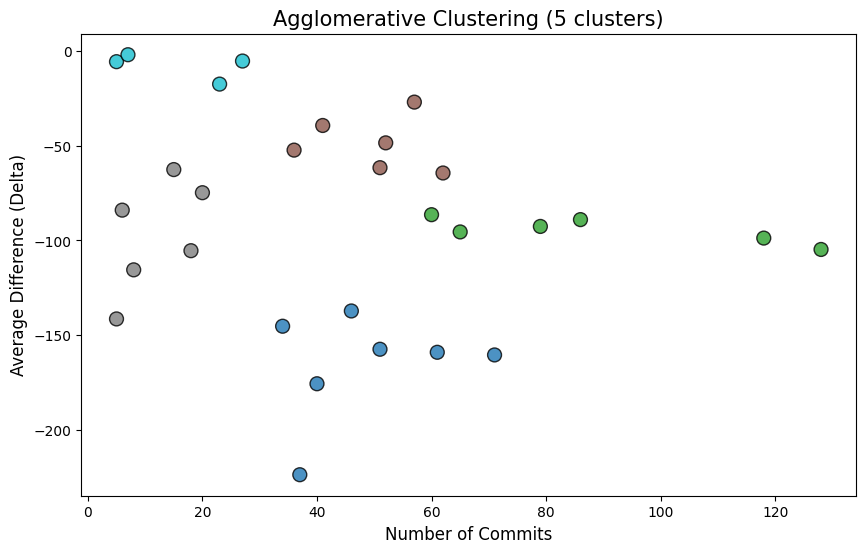

In [5]:
agg_model = AgglomerativeClustering(n_clusters=5)

labels_agg = agg_model.fit_predict(X)


sil_score_agg = silhouette_score(X, labels_agg)

print(f"Silhouette Score (Agglomerative, 5 clusters): {sil_score_agg:.5f}")
plt.figure(figsize=(10, 6))
plt.scatter(X['num_commits'], X['AVG(diff)'], c=labels_agg, cmap='tab10', 
            s=100, edgecolor='black', alpha=0.8)
plt.title('Agglomerative Clustering (5 clusters)', fontsize=15)
plt.xlabel('Number of Commits', fontsize=12)
plt.ylabel('Average Difference (Delta)', fontsize=12)
plt.show()


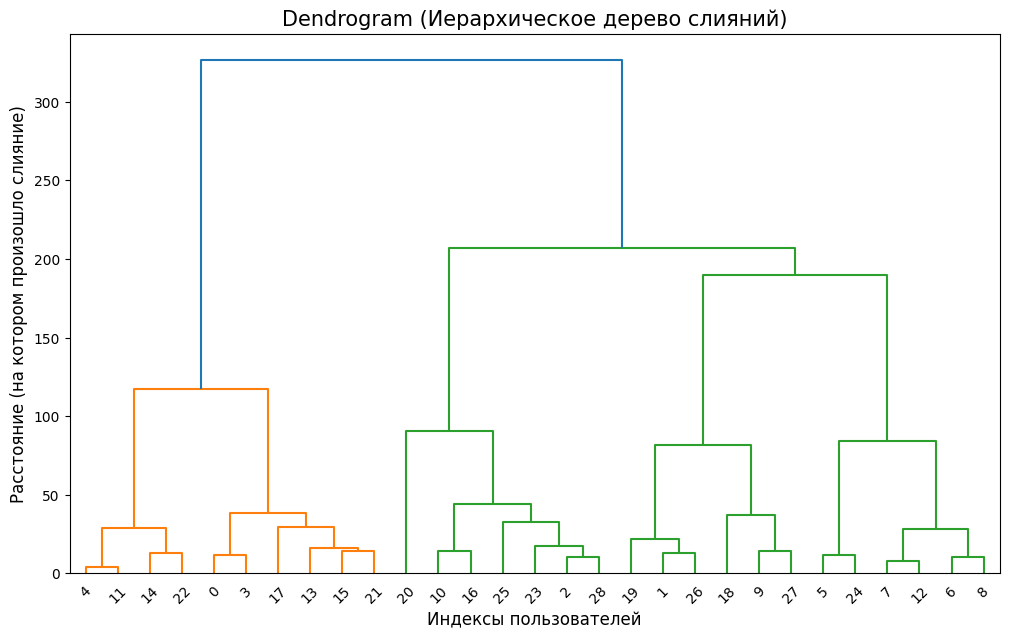

In [6]:
plt.figure(figsize=(12, 7))
plt.title("Dendrogram (Иерархическое дерево слияний)", fontsize=15)

clusters_tree = shc.linkage(X, method='ward')

dend = shc.dendrogram(clusters_tree)

plt.xlabel('Индексы пользователей', fontsize=12)
plt.ylabel('Расстояние (на котором произошло слияние)', fontsize=12)
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

KMeans
Лучший n_clusters: 3 с Silhouette Score = 0.4454402135233297


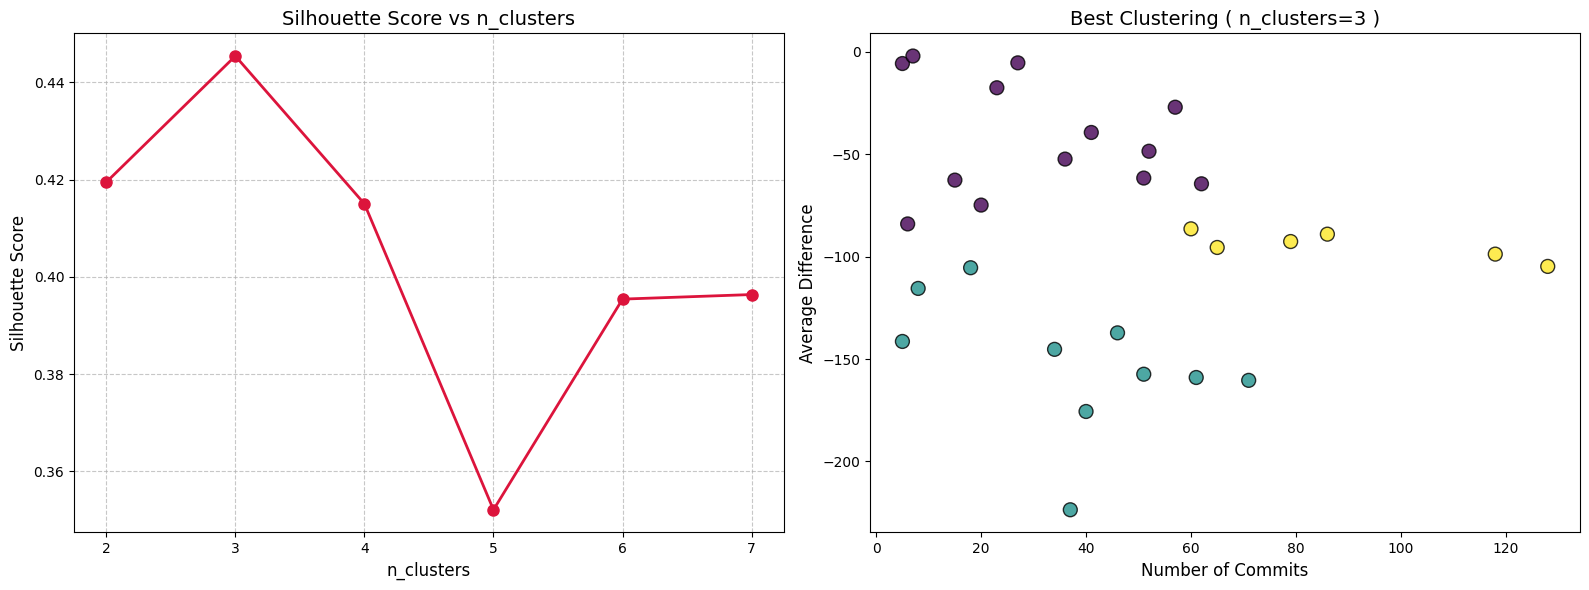


AgglomerativeClustering
Лучший n_clusters: 8 с Silhouette Score = 0.5077985556562201


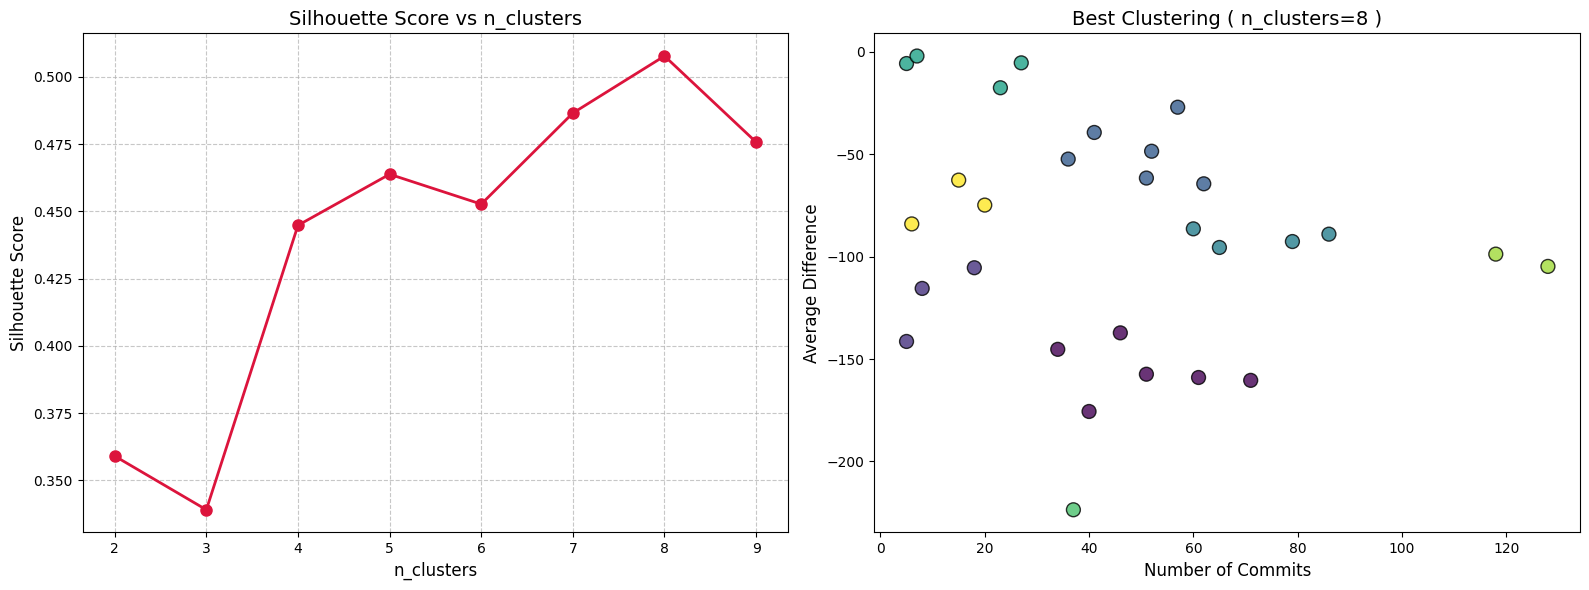


=== Тестируем DBSCAN ===
Лучший eps: 22 с Silhouette Score = 0.4794129092034348


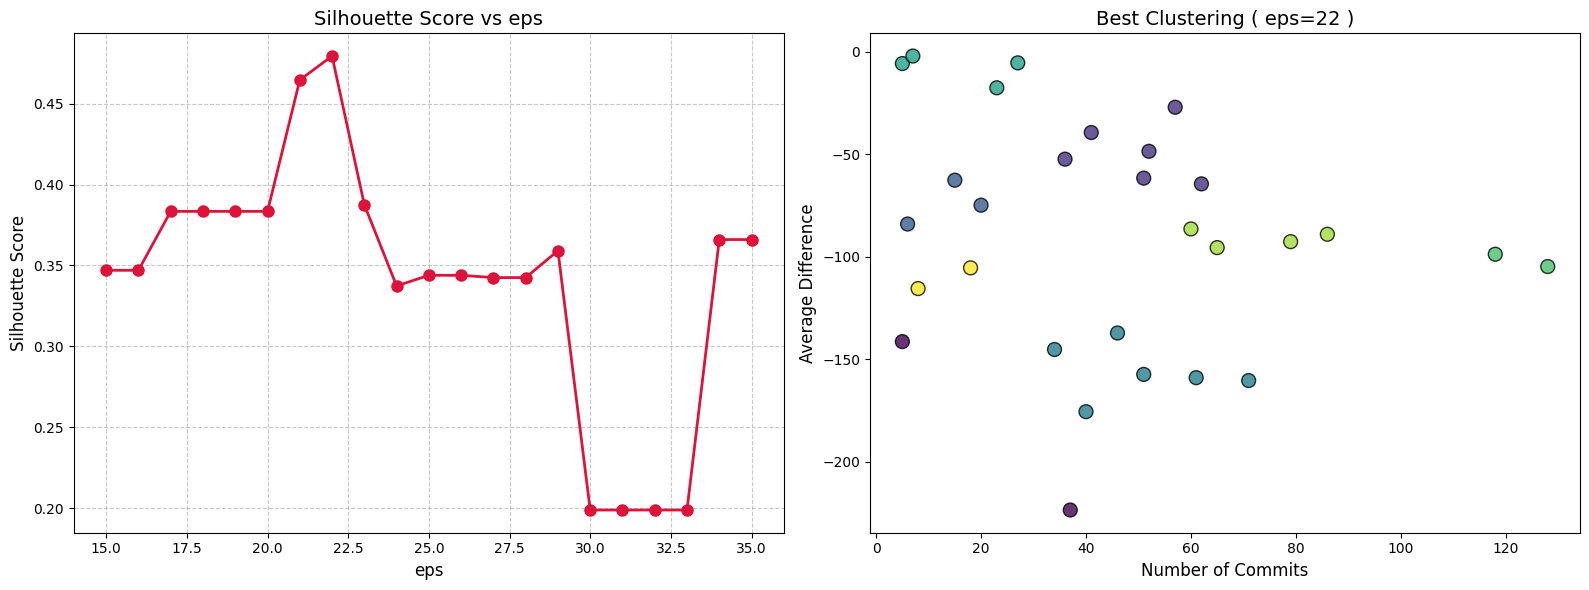

In [7]:
def optimize_clustering(model_class, base_params, param_name, param_range, X):
    scores = []
    best_score = -1
    best_param = None
    best_labels = None

    for val in param_range:
        current_params = base_params.copy()
        current_params[param_name] = val
        
        model = model_class(**current_params)
        labels = model.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if len(set(labels)) > 1 and n_clusters >= 1:
            score = silhouette_score(X, labels)
        else:
            score = -1 
            
        scores.append(score)
        
        if score > best_score:
            best_score = score
            best_param = val
            best_labels = labels
            
    print(f"Лучший {param_name}: {best_param} с Silhouette Score = {best_score}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].plot(param_range, scores, marker='o', color='crimson', linewidth=2, markersize=8)
    axes[0].set_title(f'Silhouette Score vs {param_name}', fontsize=14)
    axes[0].set_xlabel(param_name, fontsize=12)
    axes[0].set_ylabel('Silhouette Score', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    scatter = axes[1].scatter(X['num_commits'], X['AVG(diff)'], c=best_labels, 
                              cmap='viridis', s=100, edgecolor='black', alpha=0.8)
    axes[1].set_title(f'Best Clustering ( {param_name}={best_param} )', fontsize=14)
    axes[1].set_xlabel('Number of Commits', fontsize=12)
    axes[1].set_ylabel('Average Difference', fontsize=12)
    
    plt.tight_layout()
    plt.show()


print("KMeans")
optimize_clustering(KMeans, {'random_state': 21}, 'n_clusters', range(2, 8), X)

print("\nAgglomerativeClustering")
optimize_clustering(AgglomerativeClustering, {}, 'n_clusters', range(2, 10), X)

print("\n=== Тестируем DBSCAN ===")
optimize_clustering(DBSCAN, {'min_samples': 2}, 'eps', range(15, 36), X)